# Analyse ROI des compétences

## Objectif
Ce notebook identifie les compétences (skills) à plus fort retour sur investissement (ROI) à partir de deux signaux:
- le salaire moyen associé à la compétence,
- la fréquence d'apparition de la compétence dans les offres.

Le résultat final sert à prioriser les compétences à apprendre.

## 1. Import des bibliothèques
Cette étape prépare les outils nécessaires pour:
- manipuler les données,
- charger le modèle déjà entraîné,
- visualiser les résultats.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import joblib


## 2. Chargement des données et du modèle
On charge:
- le dataset encodé,
- le modèle Random Forest déjà entraîné.

Cela vérifie que l'environnement est prêt pour calculer le ROI.

In [2]:
df = pd.read_csv('dataset_encode.csv')
model = joblib.load('random_forest_model.pkl')

print('✅ Dataset et modèle chargés !')

✅ Dataset et modèle chargés !


## 3. Identification des colonnes de compétences
On sépare les variables non liées aux skills pour isoler uniquement les compétences exploitables dans l'analyse ROI.

Conclusion intermédiaire: la liste finale des skills définit l'univers de recommandation.

In [6]:
non_skills = ['job_title', 'company', 'location', 'post_date', 'seniority_level', 
              'skills', 'salary', 'skills_clean', 'seniority_encoded',
              'job_category_data engineer', 'job_category_data scientist', 
              'job_category_ml engineer', 'job_category_software engineer']

skills_cols = [col for col in df.columns if col not in non_skills]
print(skills_cols)
print(len(skills_cols))

['python', 'java', 'javascript', 'aws', 'sql', 'agile', 'git', 'c#', 'software engineering', 'c++', 'kubernetes', 'docker', 'react', 'typescript', 'software development', 'linux', 'angular', 'go', 'html', 'css', 'azure', 'unit testing', 'jira', 'microservices', 'scrum', 'devops', 'node.js', 'cloud computing', '.net', 'jenkins', 'ci/cd', 'communication', 'computer science', 'c', 'agile development', 'machine learning', 'postgresql', 'gcp', 'nosql', 'mysql', 'confluence', 'distributed systems', 'sql server', 'continuous integration', 'software design', 'rest', "'machine learning'", 'terraform', 'kafka', 'data structures']
50


## 4. Construction des indicateurs ROI par compétence
Pour chaque skill, on calcule:
- le salaire moyen observé,
- la fréquence d'apparition dans les offres.

Ces deux métriques sont la base du score ROI.

In [9]:
roi_data = []
for skill in skills_cols:
    avg_salary = df[df[skill] == 1]['salary'].mean()
    frequency = df[skill].mean()
    roi_data.append({'skill': skill, 'avg_salary': avg_salary, 'frequency': frequency})

roi_df = pd.DataFrame(roi_data)
print(roi_df.head(10))

                  skill     avg_salary  frequency
0                python  272378.479537   0.343434
1                  java  270517.275282   0.308718
2            javascript  273945.316070   0.261548
3                   aws  273519.718256   0.248701
4                   sql  271866.746968   0.218398
5                 agile  272229.660241   0.199863
6                   git  271920.243985   0.174169
7                    c#  271929.627016   0.174561
8  software engineering  273231.695795   0.171717
9                   c++  271406.661792   0.162695


## 5. Normalisation et calcul du score ROI
Les variables salaire et fréquence sont normalisées entre 0 et 1 pour être comparables.

Formule utilisée:
ROI = 0.6 × salaire_normalisé + 0.4 × fréquence_normalisée

Conclusion intermédiaire: le score privilégie davantage l'impact salaire tout en gardant la demande marché.

In [13]:
# Normaliser entre 0 et 1
roi_df['salary_norm'] = (roi_df['avg_salary'] - roi_df['avg_salary'].min()) / \
                         (roi_df['avg_salary'].max() - roi_df['avg_salary'].min())

roi_df['freq_norm'] = (roi_df['frequency'] - roi_df['frequency'].min()) / \
                       (roi_df['frequency'].max() - roi_df['frequency'].min())

# Score ROI = 60% salaire + 40% fréquence
roi_df['roi_score'] = (roi_df['salary_norm'] * 0.6) + (roi_df['freq_norm'] * 0.4)

roi_df = roi_df.sort_values('roi_score', ascending=False)
print(roi_df.columns.tolist())

['skill', 'avg_salary', 'frequency', 'salary_norm', 'freq_norm', 'roi_score']


## 6. Visualisation du Top 20 des compétences
Le graphique met en évidence les compétences au ROI le plus élevé.

Lecture rapide:
- plus la barre est longue, plus le ROI est fort,
- les 3 premières compétences sont mises en avant visuellement.

C:\Users\pc\AppData\Local\Temp\ipykernel_3604\980910571.py:10: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_3604\980910571.py:11: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('roi_final.png', dpi=150)
C:\Users\pc\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


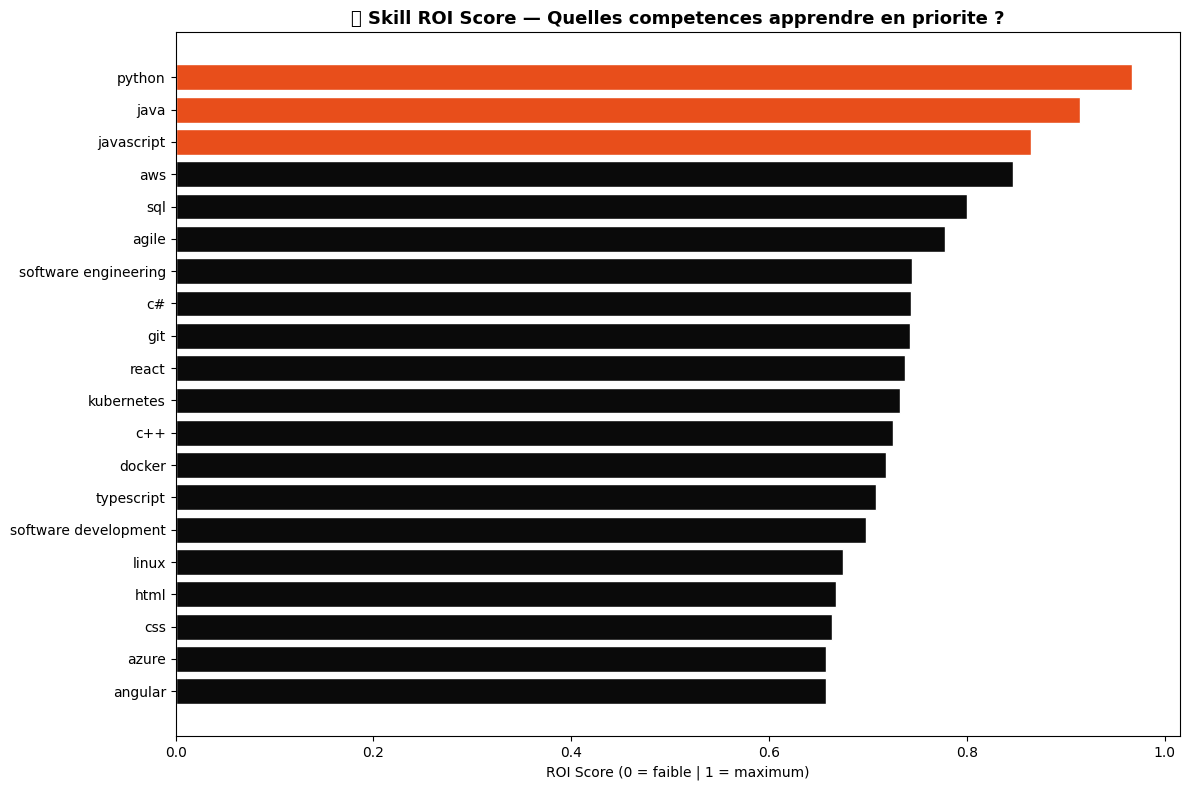

✅ Graphique sauvegarde !


In [14]:
top_20 = roi_df.head(20)

colors = ['#e84e1b' if i < 3 else '#0a0a0a' for i in range(len(top_20))]

plt.figure(figsize=(12, 8))
plt.barh(top_20['skill'][::-1], top_20['roi_score'][::-1], color=colors[::-1], edgecolor='white')
plt.title('🏆 Skill ROI Score — Quelles competences apprendre en priorite ?', 
          fontsize=13, fontweight='bold')
plt.xlabel('ROI Score (0 = faible | 1 = maximum)')
plt.tight_layout()
plt.savefig('roi_final.png', dpi=150)
plt.show()
print('✅ Graphique sauvegarde !')

## 7. Recommandations personnalisées
La fonction finale compare les compétences déjà acquises avec le classement ROI.

Objectif: proposer les prochaines compétences à apprendre selon le meilleur compromis salaire/demande.

In [16]:
def recommander_skills(mes_skills, top_n=5):
    # Trouver les skills que tu n'as pas encore
    skills_manquants = [s for s in roi_df['skill'] if s not in mes_skills]
    
    # Filtrer le ROI pour ces skills seulement
    recommandations = roi_df[roi_df['skill'].isin(skills_manquants)]
    
    print("=" * 45)
    print(f"  Tes skills actuels : {mes_skills}")
    print(f"  Top {top_n} skills a apprendre :")
    print("=" * 45)
    for i, row in recommandations.head(top_n).iterrows():
        print(f"  {row['skill']:25} ROI: {row['roi_score']:.2f}")
    print("=" * 45)

# TEST — change ces skills par les tiens !
recommander_skills(['python', 'sql'], top_n=5)
joblib.dump(roi_df, 'roi_df.pkl')
print('✅ ROI sauvegardé !')

  Tes skills actuels : ['python', 'sql']
  Top 5 skills a apprendre :
  java                      ROI: 0.91
  javascript                ROI: 0.87
  aws                       ROI: 0.85
  agile                     ROI: 0.78
  software engineering      ROI: 0.74
✅ ROI sauvegardé !


## Conclusion
Cette analyse ROI permet de prioriser les compétences à apprendre de façon quantitative.

Points clés:
- le score ROI combine valeur économique (salaire) et opportunité marché (fréquence),
- le classement obtenu fournit une feuille de route claire pour monter en compétences,
- la fonction de recommandation personnalise le plan d'apprentissage selon ton profil actuel.

Prochaine amélioration possible: adapter les poids du score ROI (60/40) selon ton objectif (salaire maximal, employabilité, ou équilibre des deux).